# Lab 1 — In-painting as Energy Minimization

*Optimization Techniques for Computer Vision*

**In-painting** means filling in missing or damaged parts of a signal: scratches on an old photo, a logo to be removed, lost samples of a recording. The problem is ill-posed, since infinitely many signals agree with the known data. We make it well-posed by choosing the solution that **minimizes an energy**, a function that is small for "plausible" signals.

In this lab you will:

1. fill gaps in a **1D signal** with harmonic and biharmonic interpolation, and compare them with linear prediction;
2. formulate **harmonic in-painting** of images as a constrained least-squares problem and solve it with a sparse direct solver;
3. compare **iterative solvers** (gradient descent, Jacobi, steepest descent, conjugate gradient) and relate their speed to the **condition number**;
4. replace the membrane model by a thin plate: **biharmonic in-painting**, and compare both models on holes and on **sparse random samples**;
5. apply the methods to an **image of your choice**;
6. *(optional bonus)* implement **2D linear prediction**.

### How to work

* **Cell legend**
    * 📘 **blue banner**: theory. Read it; the questions build on it.
    * 🟨 **yellow banner / `# 🟨 YOUR CODE HERE`**: code you must complete (replace the `raise NotImplementedError`).
    * 🟩 **green banner / `# 🟩 ANSWER CELL`**: a question, followed by the cell where you give your answer with `answer("Qx.y", ...)`. Executing it shows your answer in a **green box**.
* Many numerical answers are computed by the provided code once your implementation is correct. For multiple-choice questions, write the letter and a short justification.
* Follow the specifications in the comments (stopping rules, parameter values), so that your numbers can be compared with the reference.

### Hand-in

1. `Runtime → Restart session and run all`, and check that **no cell fails**.
2. Check that every green answer box shows your answer.
3. `File → Download → Download .ipynb`, and upload that file **with all outputs**.

### Contents
0. Setup
1. Filling gaps in a 1D signal
2. Harmonic in-painting of images
3. Iterative solvers and convergence
4. Biharmonic in-painting
5. Your own in-painting problem
* Bonus exercise: 2D linear prediction

---
## 0. Setup

In [3]:
# Only the standard scientific stack (all preinstalled on Colab)
import functools

import numpy as np
import scipy.sparse as sp                 # sparse matrices
import scipy.sparse.linalg as spla        # sparse solvers and eigenvalues
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw          # drawing damage masks, loading images
from IPython.display import HTML, display

plt.rcParams["figure.dpi"] = 90
np.set_printoptions(precision=4, suppress=True)

**Random seeds.** The test signal, the gap positions, the damage masks and the sampled pixels are generated with NumPy's pseudo-random number generator. A pseudo-random generator produces a deterministic sequence that only *looks* random; the **seed** is the number that sets its initial state. The same seed always gives the same sequence, so fixing the seeds makes the whole notebook **reproducible**: re-running it gives exactly the same data and results, and your numbers can be compared with the reference solution. Each experiment draws from its own generator, `np.random.default_rng(seed)`, with the seeds defined below; changing one seed gives a different (but again reproducible) instance of that experiment only.

In [4]:
SEED_SIGNAL = 1     # Part 1: test signal and gap positions
SEED_MASK = 2       # Parts 2-4: damage mask of the test image
SEED_SAMPLES = 3    # Part 4: randomly preserved pixels
SEED_OWN = 7        # Part 5: example mask

In [5]:
# ---------------------------------------------------------------
# Answer display: shows an answer in a green box (orange if still missing)
# ---------------------------------------------------------------
def answer(qid, value):
    if value is None or (isinstance(value, str) and value.strip() in ("", "?")):
        style = "background:#fef7e0;border-left:6px solid #f9ab00;color:#7a4f01"
        text = "⚠️ not answered yet"
    else:
        style = "background:#e6f4ea;border-left:6px solid #34a853;color:#1e4620"
        text = f"{value:.5g}" if isinstance(value, (float, np.floating)) else str(value)
    display(HTML(f'<div style="{style};padding:6px 10px;font-family:monospace;font-size:14px">'
                 f'🟩 <b>{qid}</b>: {text}</div>'))

In [6]:
# ---------------------------------------------------------------
# Display and quality-metric helpers
# ---------------------------------------------------------------
def show(images, titles=None, cmap="gray", vmin=0, vmax=1, size=3.3):
    # Show a list of images side by side (grayscale or RGB, values in [0, 1])
    images = list(images)
    fig, axes = plt.subplots(1, len(images), figsize=(size * len(images), size))
    for k, (ax, im) in enumerate(zip(np.atleast_1d(axes), images)):
        if im.ndim == 3:
            ax.imshow(np.clip(im, 0, 1))
        else:
            ax.imshow(im, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_axis_off()
        if titles is not None:
            ax.set_title(titles[k], fontsize=9)
    plt.tight_layout()
    plt.show()

def with_hole(img, hole, color=(1.0, 0.0, 0.0)):
    # RGB visualization of a grayscale image with the hole painted red
    rgb = np.repeat(img[..., None], 3, axis=2)
    rgb[hole] = color
    return rgb

def rmse(u, ref, region=None):
    # Root-mean-square error, optionally restricted to a boolean region
    d = (u - ref) if region is None else (u - ref)[region]
    return float(np.sqrt(np.mean(d ** 2)))

def psnr(u, ref, region=None):
    # Peak signal-to-noise ratio in dB, for signals with peak value 1
    return float(20 * np.log10(1.0 / rmse(u, ref, region)))

In [7]:
# ---------------------------------------------------------------
# Test data helpers
# ---------------------------------------------------------------
def load_test_image(name="astronaut", size=256):
    # Grayscale test image bundled with scikit-image (preinstalled on Colab, no download).
    # 'astronaut' is a public-domain NASA photo; 'coffee' and 'chelsea' are CC0.
    from skimage import data
    img = getattr(data, name)()
    h, w = img.shape[:2]
    s = min(h, w)                                            # center crop to a square
    img = img[(h - s) // 2:(h - s) // 2 + s, (w - s) // 2:(w - s) // 2 + s]
    img = np.asarray(Image.fromarray(img).resize((size, size), Image.LANCZOS)).astype(float) / 255
    if img.ndim == 3:
        img = img[..., :3] @ np.array([0.299, 0.587, 0.114])  # luminance
    return np.clip(img, 0, 1)

def scribble_mask(shape, rng, n_strokes=5, width=(3, 7), n_blobs=2, radius=(6, 12)):
    # Random damage: thick polylines ("scratches") + filled ellipses ("blotches").
    # Returns a boolean array: True = missing pixel (hole).
    H, W = shape
    canvas = Image.new("L", (W, H), 0)
    draw = ImageDraw.Draw(canvas)
    for _ in range(n_strokes):
        pts = [(float(rng.uniform(0.1 * W, 0.9 * W)), float(rng.uniform(0.1 * H, 0.9 * H))) for _ in range(3)]
        draw.line(pts, fill=255, width=int(rng.integers(width[0], width[1] + 1)), joint="curve")
    for _ in range(n_blobs):
        cx, cy = rng.uniform(0.15 * W, 0.85 * W), rng.uniform(0.15 * H, 0.85 * H)
        rx, ry = rng.uniform(radius[0], radius[1], size=2)
        draw.ellipse([cx - rx, cy - ry, cx + rx, cy + ry], fill=255)
    return np.asarray(canvas) > 127

---
## 1. Filling gaps in a 1D signal

<div style="background-color:#e8f0fe; border-left:6px solid #4285f4; padding:6px 12px; font-weight:bold; color:#174ea6;">📘 1.1 Problem statement</div>

Consider a sampled 1D signal $f\in\mathbb{R}^N$: a sound, a sensor time series, one row of an image... Some consecutive samples were lost (a dropped packet, a sensor failure). We split the indices into

* $K$: the **known** samples, where we trust $f$,
* $U$: the **unknown** samples (the gap),

and look for a signal $u\in\mathbb{R}^N$ that agrees with the data where it is known and is "plausible" in the gap. The energy approach formalizes "plausible" through an energy $E(u)$ and solves

$$
\min_{u\in\mathbb{R}^N}\; E(u) \quad\text{subject to}\quad u_K = f_K .
$$

Everything in this lab is a variation on this recipe: change the energy, or change the way the minimization is carried out.

<div style="background-color:#e8f0fe; border-left:6px solid #4285f4; padding:6px 12px; font-weight:bold; color:#174ea6;">📘 1.2 Quadratic energies and the reduced system</div>

**Discrete derivatives.** We write $\nabla$ for the forward-difference operator and $\Delta$ for the second-difference operator (the discrete 1D Laplacian):

$$
(\nabla u)_k = u_{k+1}-u_k, \qquad (\Delta u)_k = u_{k+2}-2u_{k+1}+u_k .
$$

As matrices, $\nabla\in\mathbb{R}^{(N-1)\times N}$ and $\Delta\in\mathbb{R}^{(N-2)\times N}$.

**Quadratic energies.** Both energies used in this lab have the form $E(u)=\tfrac12\|Gu\|^2 = \tfrac12\,u^\top Q\,u$ with $Q=G^\top G$ symmetric positive semi-definite:

$$
\begin{array}{l|c|c|c|c}
 & \text{energy} & Q & \text{optimality condition in the gap} & \text{solution in the gap}\\ \hline
\textbf{harmonic} & \tfrac12\|\nabla u\|^2=\tfrac12\sum_k (u_{k+1}-u_k)^2 & \nabla^\top\nabla & u''=0\ \ (\text{rows } {-1},\,2,\,{-1}) & \text{straight line}\\
\textbf{biharmonic} & \tfrac12\|\Delta u\|^2=\tfrac12\sum_k (u_{k+2}-2u_{k+1}+u_k)^2 & \Delta^\top\Delta & u''''=0\ \ (\text{rows } 1,\,{-4},\,6,\,{-4},\,1) & \text{cubic polynomial}
\end{array}
$$

A straight line is fixed by the two samples adjacent to the gap: harmonic in-painting in 1D is **linear interpolation**. A cubic has four degrees of freedom, fixed by two samples on each side, so the biharmonic fill matches both the **values and the slopes** at the gap ends (no kink). $\tfrac12\|\Delta u\|^2$ is the bending energy of a thin elastic beam: this is how cubic splines arise.

**Where do the names come from?** A function is called **harmonic** if it satisfies the **Laplace equation** $\Delta u = 0$, and **biharmonic** if it satisfies $\Delta^2 u = \Delta(\Delta u) = 0$ ("bi": the Laplacian applied twice). Harmonic in-painting fills the gap with a (discrete) harmonic function, and biharmonic in-painting with a biharmonic one. The word is historical: it comes from potential theory, where the solutions of Laplace's equation on a sphere (*spherical harmonics*) generalize the sines and cosines that describe the harmonics (overtones) of a vibrating string. In 1D, harmonic functions are simply straight lines and biharmonic functions are cubics. In 2D (Part 2), harmonic functions have the **mean-value property**: the value at a point is the average of the values on any circle around it.

**Eliminating the constraint.** Order the unknowns as $u=(u_U,u_K)$ and split $Q$ into blocks:

$$
E(u) = \tfrac12\, u_U^\top Q_{UU}\, u_U + u_U^\top Q_{UK}\, f_K + \tfrac12\, f_K^\top Q_{KK}\, f_K .
$$

Only $u_U$ is free. Setting the gradient with respect to $u_U$ to zero gives the **reduced system**

$$
\boxed{\;Q_{UU}\,u_U = -\,Q_{UK}\,f_K\;}
$$

$Q_{UU}$ is symmetric positive **definite** (unique solution) as long as every gap is bounded by known samples.

<div style="background-color:#e8f0fe; border-left:6px solid #4285f4; padding:6px 12px; font-weight:bold; color:#174ea6;">📘 1.3 For comparison: linear prediction</div>

Smoothness energies are minimized by the *flattest* curve through the gap. If the signal **oscillates** (sound!), they cannot know it, and for gaps longer than about one period they kill the oscillation.

A different prior is that the signal is locally **predictable** from its own past. An **autoregressive (AR) model** of order $p$ assumes $x[n]\approx\sum_{k=1}^p a_k\,x[n-k]$. For example, a sinusoid satisfies exactly $x[n]=2\cos(\omega)\,x[n-1]-x[n-2]$. The coefficients are fitted by **least squares** on the known samples next to the gap; the signal is then extrapolated forward from the left and backward from the right, and the two extrapolations are cross-faded. This method is **provided** below (you do not need to implement it).

*A useful connection.* $(\nabla u)_k=u_{k+1}-u_k$ is the error of the trivial predictor "$u_{k+1}\approx u_k$", and $(\Delta u)_k$ is the error of linear extrapolation "$u_{k+2}\approx 2u_{k+1}-u_k$". Harmonic and biharmonic in-painting therefore minimize the energy of a prediction error with **fixed** coefficients of order 1 and 2, while linear prediction **learns** the coefficients from the data.

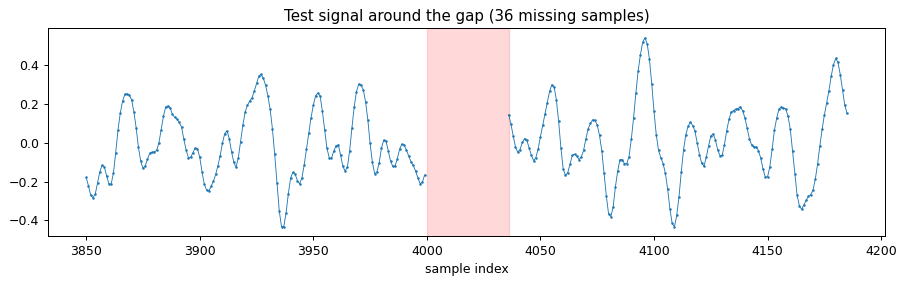

In [8]:
def make_test_signal(rng, N=8000):
    # Synthetic oscillating signal: 3 "notes" with 3 harmonics each, slow decay, weak noise
    t = np.arange(N) / N
    x = np.zeros(N)
    for f0 in rng.uniform(150, 400, size=3):                # fundamental frequencies (cycles per signal length)
        for h, amp in zip([1, 2, 3], [1.0, 0.5, 0.25]):     # harmonics and their amplitudes
            x += amp * np.sin(2 * np.pi * h * f0 * t + rng.uniform(0, 2 * np.pi))
    x *= np.exp(-t)                                         # slow decay
    x /= np.max(np.abs(x))
    return 0.9 * x + 0.003 * rng.standard_normal(N)         # weak noise

def make_gap(N, start, length):
    # Boolean vector of known samples: False inside the gap [start, start+length)
    known = np.ones(N, dtype=bool)
    known[start:start + length] = False
    return known

rng1 = np.random.default_rng(SEED_SIGNAL)
sig = make_test_signal(rng1)
N1 = len(sig)
gap_start, gap_len = 4000, 36
known1 = make_gap(N1, gap_start, gap_len)

zoom = slice(gap_start - 150, gap_start + gap_len + 150)
plt.figure(figsize=(12, 3))
plt.plot(np.arange(N1)[zoom], np.where(known1, sig, np.nan)[zoom], ".-", ms=2, lw=0.7)
plt.axvspan(gap_start, gap_start + gap_len, color="r", alpha=0.15)
plt.title(f"Test signal around the gap ({gap_len} missing samples)"); plt.xlabel("sample index"); plt.show()

In [9]:
def grad_1d(N):
    # Forward differences (nabla): (N-1) x N sparse matrix
    return sp.diags([-np.ones(N - 1), np.ones(N - 1)], [0, 1], shape=(N - 1, N), format="csr")

def lap_1d(N):
    # Second differences (Delta = discrete 1D Laplacian): (N-2) x N sparse matrix
    return (grad_1d(N - 1) @ grad_1d(N)).tocsr()

print("Delta for N=6:\n", lap_1d(6).toarray())

Delta for N=6:
 [[ 1. -2.  1.  0.  0.  0.]
 [ 0.  1. -2.  1.  0.  0.]
 [ 0.  0.  1. -2.  1.  0.]
 [ 0.  0.  0.  1. -2.  1.]]


<div style="background-color:#fef7e0; border-left:6px solid #f9ab00; padding:6px 12px; font-weight:bold; color:#7a4f01;">🟨 TODO 1 — harmonic and biharmonic interpolation</div>


1. `solve_constrained_quadratic(Q, f, known)`: build the reduced system of Section 1.2 and solve it with `spla.spsolve`.
   *Hints:* `np.flatnonzero(mask)` returns the indices of the `True` entries; for a CSR matrix, `Q[rows][:, cols]` extracts a sub-matrix; convert to CSC (`.tocsc()`) before `spsolve`.
2. `inpaint_harmonic_1d` and `inpaint_biharmonic_1d`: build $Q$ and call the solver.

This solver is reused for images in the rest of the lab.



In [10]:
def solve_constrained_quadratic(Q, f, known):
    # Minimize 1/2 u^T Q u  subject to  u[known] = f[known]
    #   Q     : (N, N) sparse symmetric positive semi-definite matrix
    #   f     : (N,) data; entries at unknown positions are ignored
    #   known : (N,) boolean, True where the value is known
    # Returns the full solution u (N,), with u[known] = f[known].
    Q = sp.csr_matrix(Q)
    u = np.array(f, dtype=float).copy()

    # Find unknown and known indices
    U = np.flatnonzero(~known)
    K = np.flatnonzero(known)

    # Extract the reduced system
    Q_UU = Q[U][:, U]
    Q_UK = Q[U][:, K]

    # Build the right-hand side
    b = -(Q_UK @ f[K])

    # Solve Q_UU @ u_U = b
    u_U = spla.spsolve(Q_UU.tocsc(), b)

    # Insert the solution into the unknown positions
    u[U] = u_U

    return u

def inpaint_harmonic_1d(f, known):
    # 🟨 YOUR CODE HERE
    N = len(f)
    G = grad_1d(N)
    Q = G.T @ G

    return solve_constrained_quadratic(Q, f, known)

def inpaint_biharmonic_1d(f, known):
    # 🟨 YOUR CODE HERE
    N = len(f)
    L = lap_1d(N)
    Q = L.T @ L

    return solve_constrained_quadratic(Q, f, known)

# quick check: linear interpolation between 0 and 3
print(inpaint_harmonic_1d(np.array([0., 99, 99, 3, 3]), np.array([True, False, False, True, True])))

[0. 1. 2. 3. 3.]


In [11]:
# Linear prediction (provided, for comparison)
def lp_fit(x, p):
    # Least-squares AR coefficients a such that x[n] ≈ sum_{k=1..p} a[k-1] x[n-k], for n = p..len(x)-1
    T = len(x)
    X = np.column_stack([x[p - k:T - k] for k in range(1, p + 1)])   # column k-1 holds x[n-k]
    a, *_ = np.linalg.lstsq(X, x[p:], rcond=None)
    return a

def lp_extrapolate(history, a, L):
    # Continue `history` for L samples with the AR recursion, feeding predictions back
    buf = list(history[-len(a):])
    out = np.empty(L)
    for m in range(L):
        out[m] = np.dot(a, buf[::-1])
        buf = buf[1:] + [out[m]]
    return out

def inpaint_lp(f, start, L, p=64, T=1000):
    # Forward/backward linear prediction (order p, trained on T samples on each side) + linear cross-fade
    left = f[start - T:start]
    right = f[start + L:start + L + T][::-1]
    fwd = lp_extrapolate(left, lp_fit(left, p), L)
    bwd = lp_extrapolate(right, lp_fit(right, p), L)[::-1]
    w = np.arange(1, L + 1) / (L + 1)
    u = np.array(f, dtype=float).copy()
    u[start:start + L] = (1 - w) * fwd + w * bwd
    return u

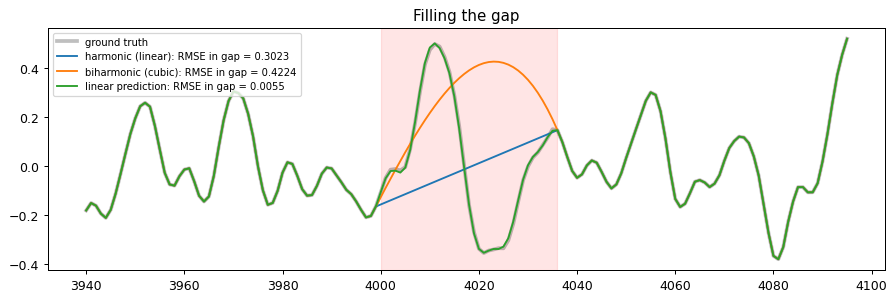

In [12]:
fills = {"harmonic (linear)": inpaint_harmonic_1d(sig, known1),
         "biharmonic (cubic)": inpaint_biharmonic_1d(sig, known1),
         "linear prediction": inpaint_lp(sig, gap_start, gap_len)}
gap = ~known1
zoom = slice(gap_start - 60, gap_start + gap_len + 60)
n = np.arange(N1)[zoom]
plt.figure(figsize=(12, 3.5))
plt.plot(n, sig[zoom], "k-", lw=3, alpha=0.25, label="ground truth")
for name, u in fills.items():
    plt.plot(n, u[zoom], label=f"{name}: RMSE in gap = {rmse(u, sig, gap):.4f}")
plt.axvspan(gap_start, gap_start + gap_len, color="r", alpha=0.1)
plt.legend(fontsize=8); plt.title("Filling the gap"); plt.show()

<div style="background-color:#e6f4ea; border-left:6px solid #34a853; padding:6px 12px; font-weight:bold; color:#1e4620;">🟩 Question Q1.1 — answer in the green cell below</div>

**Q1.1.** RMSE inside the gap of the three methods. *(Computed automatically.)*

In [13]:
# 🟩🟩🟩 ANSWER CELL — Q1.1 🟩🟩🟩
answer("Q1.1", ",  ".join(f"{k}: {rmse(u, sig, gap):.4f}" for k, u in fills.items()))

### How does the gap length matter?

We repeat the experiment for gap lengths $L\in\{2,4,\dots,256\}$, averaging the RMSE over 6 gap positions.

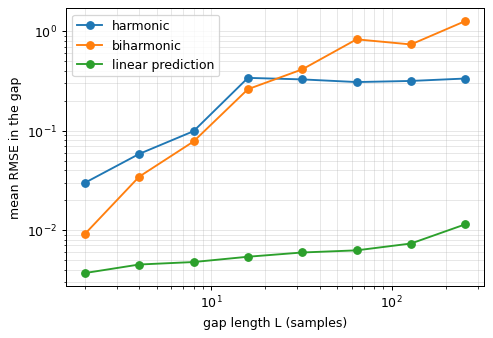

In [14]:
lengths = [2, 4, 8, 16, 32, 64, 128, 256]
starts = rng1.integers(1000, 6700, size=6)       # leaves room for 1000 training samples on both sides
err = {"harmonic": [], "biharmonic": [], "linear prediction": []}
for L in lengths:
    e = {k: [] for k in err}
    for s0 in starts:
        kn = make_gap(N1, s0, L)
        e["harmonic"].append(rmse(inpaint_harmonic_1d(sig, kn), sig, ~kn))
        e["biharmonic"].append(rmse(inpaint_biharmonic_1d(sig, kn), sig, ~kn))
        e["linear prediction"].append(rmse(inpaint_lp(sig, s0, L), sig, ~kn))
    for k in err:
        err[k].append(np.mean(e[k]))

plt.figure(figsize=(6, 4))
for k, v in err.items():
    plt.loglog(lengths, v, "o-", label=k)
plt.xlabel("gap length L (samples)"); plt.ylabel("mean RMSE in the gap"); plt.grid(True, which="both", alpha=0.3)
plt.legend(); plt.show()

<div style="background-color:#e6f4ea; border-left:6px solid #34a853; padding:6px 12px; font-weight:bold; color:#1e4620;">🟩 Question Q1.2 — answer in the green cell below</div>

**Q1.2.** What is the **largest** gap length $L$ in the list for which **biharmonic** interpolation has a lower mean RMSE than **harmonic** interpolation? Compute it from `err`.

In [15]:
# 🟩🟩🟩 ANSWER CELL — Q1.2 🟩🟩🟩
answer("Q1.2", "It's when the gap size L is equal to 16, from there biharmonic has a higher error")   # replace None by your computation

<div style="background-color:#e6f4ea; border-left:6px solid #34a853; padding:6px 12px; font-weight:bold; color:#1e4620;">🟩 Question Q1.3 — answer in the green cell below</div>

**Q1.3.** For long gaps, harmonic and biharmonic in-painting of this signal fail because:

* **(a)** the linear systems become singular for long gaps;
* **(b)** the energies penalize oscillations, so their minimizers are the smoothest bridges across the gap, ignoring the oscillating structure of the signal;
* **(c)** the sampling rate is too low to represent the fill;
* **(d)** the sparse direct solver loses accuracy for long gaps.

Give the letter and a one-sentence justification.

In [16]:
# 🟩🟩🟩 ANSWER CELL — Q1.3 🟩🟩🟩
answer("Q1.3", "(b) because we have an oscilating signal (like in almost all cases), short gaps can be aproximated with energy based methods due to the slope not changing in value heavily. In longer gaps this slope changes with oscilation making the energy based methods worse overall.")   # e.g. "(x) because ..."

---
## 2. Harmonic in-painting of images

<div style="background-color:#e8f0fe; border-left:6px solid #4285f4; padding:6px 12px; font-weight:bold; color:#174ea6;">📘 2.1 From 1D to 2D</div>

An $H\times W$ grayscale image is stored as a vector $u\in\mathbb{R}^N$, $N=HW$, in **row-major** order: pixel $(i,j)$ has index $p=iW+j$ (this is what `img.ravel()` does).

**Differences with a Neumann boundary.** Let $\nabla_n\in\mathbb{R}^{n\times n}$ be the 1D forward-difference matrix $(\nabla_n v)_k=v_{k+1}-v_k$ for $k<n-1$, with a **zero last row**. The zero row means that no difference is measured across the image border: this is the discrete **Neumann** (zero-flux) boundary condition, and no ghost pixels are needed.

**Kronecker products.** The Kronecker product $A\otimes B$ is the block matrix $[a_{ij}B]$. The horizontal and vertical difference operators of the image are

$$
\nabla_x = I_H\otimes\nabla_W, \qquad \nabla_y = \nabla_H\otimes I_W, \qquad
\nabla = \begin{pmatrix}\nabla_x\\ \nabla_y\end{pmatrix}\in\mathbb{R}^{2N\times N}.
$$

$I_H\otimes\nabla_W$ applies $\nabla_W$ to every image row independently; $\nabla_H\otimes I_W$ differentiates along the columns.

**Dirichlet energy and Laplacian.**

$$
E(u)=\tfrac12\|\nabla u\|^2=\tfrac12\left(\|\nabla_x u\|^2+\|\nabla_y u\|^2\right)=-\tfrac12\,u^\top\Delta\,u,
\qquad \Delta = -\nabla^\top\nabla = -\left(\nabla_x^\top\nabla_x+\nabla_y^\top\nabla_y\right).
$$

$\Delta$ is the **5-point discrete Laplacian**: at an interior pixel, $(\Delta u)_{i,j}=u_{i,j+1}+u_{i,j-1}+u_{i+1,j}+u_{i-1,j}-4u_{i,j}$. Hence $\Delta u=0$ at a pixel means

$$
u_{i,j} = \tfrac14\left(u_{i,j+1}+u_{i,j-1}+u_{i+1,j}+u_{i-1,j}\right):
$$

each filled pixel is the **average of its four neighbors**, the discrete version of the mean-value property of harmonic functions (Section 1.2).

**Harmonic in-painting** minimizes $E$ subject to $u_K=f_K$. With $Q=-\Delta$, this is the reduced system of Section 1.2, i.e. the discrete **Laplace equation** $\Delta u=0$ inside the hole, with the known pixels as boundary values. **Your 1D solver works unchanged.**

<div style="background-color:#fef7e0; border-left:6px solid #f9ab00; padding:6px 12px; font-weight:bold; color:#7a4f01;">🟨 TODO 2 — the 2D difference operators</div>


Complete `grad_2d` with `sp.kron` and `sp.identity`, using the provided `grad_neumann`.

In [18]:
def grad_neumann(n):
    # n x n forward differences with a zero last row (Neumann boundary)
    main = -np.ones(n)
    main[-1] = 0.0
    return sp.diags([main, np.ones(n - 1)], [0, 1], shape=(n, n), format="csr")

@functools.lru_cache(maxsize=None)
def grad_2d(H, W):
    # Horizontal and vertical difference operators (nabla_x, nabla_y) for row-major H x W images
    # 🟨 YOUR CODE HERE
    
    Gx = sp.kron(sp.eye(H), grad_neumann(W))
    Gy = sp.kron(grad_neumann(H), sp.eye(W))  
    
    return Gx.tocsr(), Gy.tocsr()

@functools.lru_cache(maxsize=None)
def laplacian_2d(H, W):
    # Delta = -(nabla_x^T nabla_x + nabla_y^T nabla_y)
    Gx, Gy = grad_2d(H, W)
    return (-(Gx.T @ Gx + Gy.T @ Gy)).tocsr()

def inpaint_harmonic(f, known):
    # Harmonic in-painting of a 2D image (known: 2D boolean array)
    H, W = f.shape
    return solve_constrained_quadratic(-laplacian_2d(H, W), f.ravel(), known.ravel()).reshape(H, W)

# Rows of Delta, reshaped as images around their pixel: the 5-point stencil
L9 = laplacian_2d(9, 9)
print("Delta, central pixel of a 9x9 image:\n", L9[4 * 9 + 4].toarray().reshape(9, 9)[2:7, 2:7])
print("Delta, corner pixel (Neumann boundary):\n", L9[0].toarray().reshape(9, 9)[:3, :3])

Delta, central pixel of a 9x9 image:
 [[ 0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.]
 [ 0.  1. -4.  1.  0.]
 [ 0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.]]
Delta, corner pixel (Neumann boundary):
 [[-2.  1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  0.]]


image 256x256, 5185 missing pixels (7.9%)


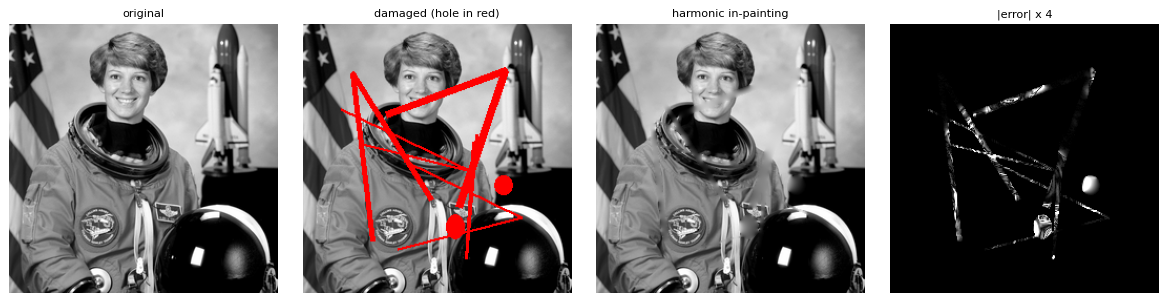

In [19]:
# Test image and damage mask
rng2 = np.random.default_rng(SEED_MASK)
img = load_test_image("astronaut", 256)
H2, W2 = img.shape
hole = scribble_mask(img.shape, rng2)
known = ~hole
f_vec, known_vec = img.ravel(), known.ravel()
print(f"image {H2}x{W2}, {hole.sum()} missing pixels ({100 * hole.mean():.1f}%)")

u_harm = inpaint_harmonic(img, known)
show([img, with_hole(img, hole), u_harm, np.abs(u_harm - img) * 4],
     ["original", "damaged (hole in red)", "harmonic in-painting", "|error| x 4"])

<div style="background-color:#e6f4ea; border-left:6px solid #34a853; padding:6px 12px; font-weight:bold; color:#1e4620;">🟩 Question Q2.1 — answer in the green cell below</div>

**Q2.1.** PSNR (in dB) of the harmonic in-painting, measured **inside the hole** only. *(Computed automatically.)*

In [20]:
# 🟩🟩🟩 ANSWER CELL — Q2.1 🟩🟩🟩
answer("Q2.1", psnr(u_harm, img, hole))

---
## 3. Iterative solvers and convergence

<div style="background-color:#e8f0fe; border-left:6px solid #4285f4; padding:6px 12px; font-weight:bold; color:#174ea6;">📘 3.1 Gradient methods on the reduced system</div>

So far we used a sparse **direct** solver (a sparse LU factorization). For large images, 3D volumes or video, factorizations become too expensive in memory and time, and **iterative** methods take over. They only need matrix–vector products.

The reduced system $A x = b$, with $A=Q_{UU}$ and $Q=-\Delta$, is **symmetric positive definite (SPD)**. It is equivalent to minimizing the strictly convex quadratic

$$
q(x) = \tfrac12\, x^\top A x - b^\top x, \qquad \nabla q(x) = Ax-b = -r, \quad r = b - Ax \ \text{(the residual)}.
$$

**Gradient descent (GD) with fixed step $\alpha$:** $x_{k+1} = x_k + \alpha\, r_k$. The error $e_k = x_k - x^\star$ evolves as $e_{k+1} = (I-\alpha A)\,e_k$. Writing $A = V\Lambda V^\top$ (eigen-decomposition), each eigen-component of the error is multiplied by $(1-\alpha\lambda_i)$ at every iteration. Hence:

* GD **converges iff** $|1-\alpha\lambda_i|<1$ for all $i$, i.e. $\;0<\alpha<2/\lambda_{\max}$;
* the best fixed step $\alpha = 2/(\lambda_{\min}+\lambda_{\max})$ gives the rate $\rho = \frac{\kappa-1}{\kappa+1}$, with the **condition number** $\kappa=\lambda_{\max}/\lambda_{\min}$;
* reducing the error by a factor $\varepsilon$ takes about $\frac{\kappa}{2}\ln\frac1\varepsilon$ iterations.

**Bounding $\lambda_{\max}$ (Gershgorin).** Every row of $-\Delta$ has a diagonal entry of at most 4 and off-diagonal entries whose absolute values sum to at most 4, so $\lambda_{\max}\le 8$.

**Jacobi iteration:** $x_{k+1} = x_k + D_A^{-1} r_k$, with $D_A=\mathrm{diag}(A)$. This is GD with a different step per unknown (a *diagonal preconditioner*). For our Laplacian, the diagonal is 4 (away from the image border), so Jacobi is essentially GD with $\alpha=1/4$.

**Steepest descent (SD):** choose the step by an **exact line search** along $r_k$:

$$
\frac{d}{d\alpha}\, q(x_k+\alpha r_k) = -r_k^\top r_k + \alpha\, r_k^\top A r_k = 0
\quad\Longrightarrow\quad
\alpha_k = \frac{r_k^\top r_k}{r_k^\top A r_k}.
$$

SD needs no knowledge of $\lambda_{\max}$, but it zig-zags and has the same $O(\kappa)$ iteration count as GD.

<div style="background-color:#e8f0fe; border-left:6px solid #4285f4; padding:6px 12px; font-weight:bold; color:#174ea6;">📘 3.2 The conjugate gradient method (CG)</div>

GD and SD follow the negative gradient, and successive steps partly undo each other. CG instead chooses search directions $p_0, p_1, \dots$ that are **$A$-conjugate**: $p_i^\top A\, p_j = 0$ for $i\neq j$. With conjugate directions, minimizing $q$ along each direction **once** is enough. After $k$ steps, $x_k$ minimizes $q$ over the whole affine space

$$
x_0 + \mathrm{span}\{r_0, A r_0, A^2 r_0, \dots, A^{k-1} r_0\} \qquad \text{(the Krylov subspace)},
$$

so in exact arithmetic CG terminates in at most $n$ steps. In practice it is used as an iterative method, with the error bound

$$
\|e_k\|_A \le 2\left(\frac{\sqrt\kappa-1}{\sqrt\kappa+1}\right)^k \|e_0\|_A
\quad\Longrightarrow\quad \text{about } \tfrac{\sqrt\kappa}{2}\ln\tfrac{2}{\varepsilon}\ \text{iterations}.
$$

The dependence on $\sqrt{\kappa}$ instead of $\kappa$ is a huge gain for ill-conditioned problems. The algorithm costs one matrix–vector product per iteration, like GD:

$$
\begin{aligned}
& r_0 = b - A x_0,\quad p_0 = r_0 \\
& \text{for } k = 0, 1, \dots:\\
&\qquad \alpha_k = \frac{r_k^\top r_k}{p_k^\top A p_k},\qquad x_{k+1} = x_k + \alpha_k p_k,\qquad r_{k+1} = r_k - \alpha_k A p_k \\
&\qquad \beta_k = \frac{r_{k+1}^\top r_{k+1}}{r_k^\top r_k},\qquad p_{k+1} = r_{k+1} + \beta_k p_k
\end{aligned}
$$

**Why CG requires an SPD matrix.** The whole construction relies on $\langle x,y\rangle_A = x^\top A y$ being an **inner product** (conjugacy is orthogonality in it) and on $q$ being strictly convex. Both need $A$ symmetric positive definite:

* with a **non-symmetric** $A$, the short recurrence loses its optimality and CG may diverge;
* with a **symmetric indefinite** $A$ (for example the matrix of a Lagrange-multiplier (KKT) formulation of the constraint), $p_k^\top A p_k$ can vanish and CG breaks down (methods such as MINRES or GMRES exist for those cases, but are beyond this lab).

This is one practical reason to **eliminate** the known pixels. A common way to code in-painting keeps all $N$ pixels as unknowns and writes an identity row $u_p=f_p$ for every known pixel. That matrix is **not symmetric**: the row of an unknown pixel next to a known pixel $q$ has a coefficient in column $q$, but row $q$ only has its diagonal entry. Eliminating the known pixels leaves $Q_{UU}$, which is SPD, and CG applies.

<div style="background-color:#e8f0fe; border-left:6px solid #4285f4; padding:6px 12px; font-weight:bold; color:#174ea6;">📘 3.3 Condition number, hole size and slow modes</div>

For a **square hole of side $w$**, the extreme eigenvalues of $A=Q_{UU}$ are approximately

$$
\lambda_{\min}\approx \frac{2\pi^2}{(w+1)^2},\qquad \lambda_{\max}\approx 8
\quad\Longrightarrow\quad \kappa \approx \frac{4(w+1)^2}{\pi^2}\;\propto\; w^2 .
$$

**Predictions:** the number of iterations of GD/Jacobi grows like $w^2$, and that of CG like $w$.

**Slow modes.** The eigenvectors of $A$ with the smallest eigenvalues are smooth "drum modes" of the hole: the vibration modes of a membrane with the shape of the hole, clamped at its border. GD multiplies each error component by $(1-\alpha\lambda_i)$, so components with small $\lambda_i$, the **smooth** ones, decay the slowest. After many iterations, the remaining error looks like the first drum mode. (This observation is the starting point of *multigrid* methods, which are not covered here.)

In [ ]:
def reduced_system(Q, f, known):
    # A = Q_UU, b = -Q_UK f_K and the indices U of the unknowns (same as inside solve_constrained_quadratic)
    Q = sp.csr_matrix(Q)
    U, K = np.flatnonzero(~known), np.flatnonzero(known)
    QU = Q[U]
    return QU[:, U].tocsr(), -(QU[:, K] @ f[K]), U

def gradient_descent(A, b, alpha, x0=None, tol=1e-8, maxit=10000):
    # Fixed-step gradient descent on q(x) = 1/2 x^T A x - b^T x.
    # alpha may be a scalar or a vector (one step per unknown).
    # Returns x and the history of relative residuals ||r_k|| / ||b||  (history[0] is for x0).
    # Stops when the relative residual is < tol, after maxit iterations, or on divergence.
    x = np.zeros_like(b) if x0 is None else x0.copy()
    r = b - A @ x
    nb = np.linalg.norm(b)
    hist = [np.linalg.norm(r) / nb]
    for k in range(maxit):
        if hist[-1] < tol:
            break
        x = x + alpha * r
        r = b - A @ x
        hist.append(np.linalg.norm(r) / nb)
        if not np.isfinite(hist[-1]) or hist[-1] > 1e8:     # diverged
            break
    return x, np.array(hist)

def jacobi(A, b, x0=None, tol=1e-8, maxit=10000):
    # Jacobi = gradient descent with the step 1/diag(A) for each unknown
    return gradient_descent(A, b, 1.0 / A.diagonal(), x0, tol, maxit)

<div style="background-color:#fef7e0; border-left:6px solid #f9ab00; padding:6px 12px; font-weight:bold; color:#7a4f01;">🟨 TODO 3.A — steepest descent and conjugate gradient</div>


Same interface and **same stopping rule** as `gradient_descent`: check the relative residual *before* each update, and record the relative residual after each update. The number of iterations performed is therefore `len(hist) - 1`. For CG, use the recursively updated residual $r_{k+1} = r_k-\alpha_k A p_k$.

In [ ]:
def steepest_descent(A, b, x0=None, tol=1e-8, maxit=10000):
    x = np.zeros_like(b) if x0 is None else x0.copy()
    r = b - A @ x
    nb = np.linalg.norm(b)
    hist = [np.linalg.norm(r) / nb]
    # 🟨 YOUR CODE HERE
    raise NotImplementedError("🟨 Complete this part")
    return x, np.array(hist)

def conjugate_gradient(A, b, x0=None, tol=1e-8, maxit=10000):
    x = np.zeros_like(b) if x0 is None else x0.copy()
    r = b - A @ x
    nb = np.linalg.norm(b)
    hist = [np.linalg.norm(r) / nb]
    # 🟨 YOUR CODE HERE
    raise NotImplementedError("🟨 Complete this part")
    return x, np.array(hist)

### Experiment 3.a — the step-size limit of gradient descent

We build the reduced system for the hole of Part 2, compute $\lambda_{\max}(A)$ with a sparse eigensolver, and run GD with steps below and slightly above $2/\lambda_{\max}$.

In [ ]:
A_h, b_h, U_h = reduced_system(-laplacian_2d(H2, W2), f_vec, known_vec)
lam_max = spla.eigsh(A_h, k=1, which="LA", return_eigenvectors=False)[0]
print(f"{A_h.shape[0]} unknowns;  lambda_max = {lam_max:.5f}  (Gershgorin bound: 8)")

plt.figure(figsize=(6, 4))
for c in [0.5, 0.95, 1.05]:
    _, h = gradient_descent(A_h, b_h, c * 2 / lam_max, tol=1e-10, maxit=1500)
    plt.semilogy(h, label=f"α = {c} · 2/λmax")
plt.ylim(1e-6, 1e6); plt.xlabel("iteration"); plt.ylabel("relative residual"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

<div style="background-color:#e6f4ea; border-left:6px solid #34a853; padding:6px 12px; font-weight:bold; color:#1e4620;">🟩 Question Q3.1 — answer in the green cell below</div>

**Q3.1.** $\lambda_{\max}$ of the reduced matrix. *(Computed automatically.)*

In [ ]:
# 🟩🟩🟩 ANSWER CELL — Q3.1 🟩🟩🟩
answer("Q3.1", lam_max)

<div style="background-color:#e6f4ea; border-left:6px solid #34a853; padding:6px 12px; font-weight:bold; color:#1e4620;">🟩 Question Q3.2 — answer in the green cell below</div>

**Q3.2.** What happens with the step $\alpha = 1.05\cdot 2/\lambda_{\max}$?

* **(a)** GD converges, but more slowly than with $0.95\cdot 2/\lambda_{\max}$;
* **(b)** GD diverges, because the component of the error along the top eigenvector is amplified by $|1-\alpha\lambda_{\max}|>1$ at every iteration;
* **(c)** GD converges faster, because the step is larger;
* **(d)** GD stagnates at a constant residual.

Give the letter and a one-sentence justification.

In [ ]:
# 🟩🟩🟩 ANSWER CELL — Q3.2 🟩🟩🟩
answer("Q3.2", "?")   # e.g. "(x) because ..."

### Experiment 3.b — comparing solvers

Same hole; tolerance $10^{-8}$ on the relative residual.

In [ ]:
x_direct = spla.spsolve(A_h.tocsc(), b_h)
runs = {
    "Jacobi": jacobi(A_h, b_h, tol=1e-8, maxit=50000),
    "steepest descent": steepest_descent(A_h, b_h, tol=1e-8, maxit=50000),
    "conjugate gradient": conjugate_gradient(A_h, b_h, tol=1e-8, maxit=50000),
}
plt.figure(figsize=(6, 4))
for name, (x, h) in runs.items():
    plt.semilogy(h, label=f"{name}: {len(h) - 1} it., error vs direct {np.abs(x - x_direct).max():.1e}")
plt.xscale("log"); plt.xlabel("iteration"); plt.ylabel("relative residual"); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.show()
it_cg = len(runs["conjugate gradient"][1]) - 1
it_jac = len(runs["Jacobi"][1]) - 1

<div style="background-color:#e6f4ea; border-left:6px solid #34a853; padding:6px 12px; font-weight:bold; color:#1e4620;">🟩 Question Q3.3 — answer in the green cell below</div>

**Q3.3.** Number of iterations needed by **CG** and by **Jacobi** to reach a relative residual below $10^{-8}$. *(Computed automatically.)*

In [ ]:
# 🟩🟩🟩 ANSWER CELL — Q3.3 🟩🟩🟩
answer("Q3.3", f"CG: {it_cg} iterations,  Jacobi: {it_jac} iterations")

### Experiment 3.c — how does the hole size affect convergence?

Square holes of side $w\in\{8,16,32,64\}$ in the middle of the image; tolerance $10^{-6}$. We also compute $\kappa$ with a sparse eigensolver.

In [ ]:
ws = [8, 16, 32, 64]
its = {"Jacobi": [], "conjugate gradient": []}
kappas = []
for w in ws:
    sq = np.zeros_like(hole)
    sq[H2 // 2 - w // 2:H2 // 2 - w // 2 + w, W2 // 2 - w // 2:W2 // 2 - w // 2 + w] = True
    A_w, b_w, _ = reduced_system(-laplacian_2d(H2, W2), f_vec, ~sq.ravel())
    its["Jacobi"].append(len(jacobi(A_w, b_w, tol=1e-6, maxit=100000)[1]) - 1)
    its["conjugate gradient"].append(len(conjugate_gradient(A_w, b_w, tol=1e-6, maxit=100000)[1]) - 1)
    lmin = spla.eigsh(A_w, k=1, sigma=0, which="LM", return_eigenvectors=False)[0]
    lmax = spla.eigsh(A_w, k=1, which="LA", return_eigenvectors=False)[0]
    kappas.append(lmax / lmin)

slopes = {k: np.polyfit(np.log(ws), np.log(v), 1)[0] for k, v in its.items()}
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for k, v in its.items():
    ax[0].loglog(ws, v, "o-", label=f"{k}: slope {slopes[k]:.2f}")
ax[0].set_xlabel("hole side w"); ax[0].set_ylabel("iterations to 1e-6"); ax[0].legend(); ax[0].grid(True, which="both", alpha=0.3)
ax[1].loglog(ws, kappas, "o-", label="measured κ")
ax[1].loglog(ws, [4 * (w + 1) ** 2 / np.pi ** 2 for w in ws], "--", label="4(w+1)²/π²")
ax[1].set_xlabel("hole side w"); ax[1].set_ylabel("condition number"); ax[1].legend(); ax[1].grid(True, which="both", alpha=0.3)
plt.show()
print("iterations:", its)

<div style="background-color:#e6f4ea; border-left:6px solid #34a853; padding:6px 12px; font-weight:bold; color:#1e4620;">🟩 Question Q3.4 — answer in the green cell below</div>

**Q3.4.** Fitted log–log slopes of the iteration counts versus $w$ for Jacobi and CG. Do they agree with the predictions of Section 3.3? *(Slopes computed automatically; add a short comment.)*

In [ ]:
# 🟩🟩🟩 ANSWER CELL — Q3.4 🟩🟩🟩
answer("Q3.4", f"Jacobi: {slopes['Jacobi']:.2f}, CG: {slopes['conjugate gradient']:.2f}. ?")   # replace ? by your comment

### Experiment 3.d — slow modes

An L-shaped hole. We compute the four eigenvectors of $A$ with the smallest eigenvalues, run 600 Jacobi iterations, and compare the remaining error with the first eigenvector.

In [ ]:
L_hole = np.zeros_like(hole)
L_hole[100:160, 90:115] = True        # vertical bar of the "L"
L_hole[135:160, 90:170] = True        # horizontal bar
A_L, b_L, U_L = reduced_system(-laplacian_2d(H2, W2), f_vec, ~L_hole.ravel())
vals, vecs = spla.eigsh(A_L, k=4, sigma=0, which="LM")
x_star = spla.spsolve(A_L.tocsc(), b_L)
x_600, _ = jacobi(A_L, b_L, tol=0, maxit=600)
err600 = x_600 - x_star
cos_mode = abs(err600 @ vecs[:, 0]) / np.linalg.norm(err600)

def on_hole(v, hole2d):
    # Place the values of v (one per hole pixel) back into an image, NaN elsewhere
    im = np.full(hole2d.size, np.nan)
    im[np.flatnonzero(hole2d.ravel())] = v
    return im.reshape(hole2d.shape)[90:170, 80:180]

fig, ax = plt.subplots(1, 5, figsize=(16, 3))
for k in range(4):
    ax[k].imshow(on_hole(vecs[:, k], L_hole), cmap="RdBu"); ax[k].set_title(f"mode {k + 1}, λ={vals[k]:.4f}", fontsize=9)
ax[4].imshow(on_hole(err600, L_hole), cmap="RdBu"); ax[4].set_title(f"Jacobi error after 600 it.\n|cos| with mode 1 = {cos_mode:.3f}", fontsize=9)
for a in ax: a.set_axis_off()
plt.show()

<div style="background-color:#e6f4ea; border-left:6px solid #34a853; padding:6px 12px; font-weight:bold; color:#1e4620;">🟩 Question Q3.5 — answer in the green cell below</div>

**Q3.5.** Which statement best explains why the error of Jacobi/GD becomes smooth after many iterations?

* **(a)** Jacobi averages neighboring pixels, so it only removes noise and cannot converge to $x^\star$;
* **(b)** the error components along eigenvectors with small eigenvalues (smooth modes) are multiplied by factors closest to 1, so they decay the slowest;
* **(c)** rounding errors accumulate in the smooth modes;
* **(d)** the largest eigenvalues correspond to smooth modes, which are amplified.

Give the letter and a one-sentence justification (use the value of $|\cos|$ printed above).

In [ ]:
# 🟩🟩🟩 ANSWER CELL — Q3.5 🟩🟩🟩
answer("Q3.5", "?")   # e.g. "(x) because ..."

---
## 4. Biharmonic in-painting

<div style="background-color:#e8f0fe; border-left:6px solid #4285f4; padding:6px 12px; font-weight:bold; color:#174ea6;">📘 4.1 Membranes and plates</div>

Harmonic in-painting behaves like a **membrane** (a rubber sheet) stretched over the hole and pinned at its border. It minimizes **slopes**, with two visible consequences:

* **maximum principle:** the fill never leaves the range of the boundary values (no overshoot);
* **kinks:** the gradient is generally discontinuous across the hole border, so large holes look "flat" and creased.

A **thin plate** resists **bending** (curvature) instead. The biharmonic energy is the 2D analogue of the 1D energy $\tfrac12\|\Delta u\|^2$ of Section 1.2:

$$
E_2(u)=\tfrac12\,\|\Delta u\|^2=\tfrac12\,u^\top(\Delta^\top\Delta)\,u ,
$$

and its optimality condition is the **biharmonic equation** $\Delta^2u=0$ in the hole (a 13-point stencil).

* The fill continues the **gradients** of the image across the hole border: smoother, "rounder" fills.
* The stencil has radius 2, so two rings of known pixels around the hole take part.
* There is **no maximum principle**: near sharp edges the fill can **overshoot** (values outside the range of the data, even outside $[0,1]$), so we clip the result. The harmonic fill, in contrast, can never leave the range of its boundary values.

Nothing changes in the code: biharmonic in-painting is `solve_constrained_quadratic` with $Q=\Delta^\top\Delta$ instead of $Q=-\Delta$.

<div style="background-color:#fef7e0; border-left:6px solid #f9ab00; padding:6px 12px; font-weight:bold; color:#7a4f01;">🟨 TODO 4 — biharmonic in-painting</div>

In [ ]:
def inpaint_biharmonic(f, known, clip=True):
    # Biharmonic in-painting of a 2D image; the result is clipped to [0, 1] if clip=True
    H, W = f.shape
    # 🟨 YOUR CODE HERE
    raise NotImplementedError("🟨 Complete this part")
    return np.clip(u, 0, 1) if clip else u

u_bih = inpaint_biharmonic(img, known)
show([with_hole(img, hole), u_harm, u_bih],
     ["damaged", f"harmonic: {psnr(u_harm, img, hole):.2f} dB", f"biharmonic: {psnr(u_bih, img, hole):.2f} dB"], size=4)
r0, c0 = np.argwhere(hole)[0]
win = (slice(max(r0 - 20, 0), r0 + 44), slice(max(c0 - 20, 0), c0 + 44))
show([img[win], with_hole(img, hole)[win], u_harm[win], u_bih[win]], ["original (zoom)", "damaged", "harmonic", "biharmonic"])

<div style="background-color:#e6f4ea; border-left:6px solid #34a853; padding:6px 12px; font-weight:bold; color:#1e4620;">🟩 Question Q4.1 — answer in the green cell below</div>

**Q4.1.** PSNR inside the hole of the **biharmonic** in-painting. *(Computed automatically.)*

In [ ]:
# 🟩🟩🟩 ANSWER CELL — Q4.1 🟩🟩🟩
answer("Q4.1", psnr(u_bih, img, hole))

### Experiment 4.b — smooth images versus sharp edges

Two synthetic $128\times128$ test cases: a **smooth** image with a large round hole, and a **piecewise-constant** image (flat regions, sharp edges) with thin holes crossing its edges. The bottom row shows a profile across the hole, *without* clipping.

In [ ]:
yy, xx = np.mgrid[0:128, 0:128]
smooth = 0.5 + 0.3 * np.sin(xx / 11.0) * np.cos(yy / 15.0)
disk = (yy - 64) ** 2 + (xx - 64) ** 2 < 22 ** 2
blocks = np.full((128, 128), 0.1)
blocks[20:60, :] = 0.8
blocks[:, 70:100] = 0.3
blocks[80:110, 10:50] = 0.9
strips = np.zeros((128, 128), dtype=bool)
strips[:, 55:62] = True
strips[64:70, :] = True

cases = {"smooth": (smooth, disk, 64), "blocks": (blocks, strips, 30)}
results = {}
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
for col, (name, (clean, hl, row)) in enumerate(cases.items()):
    uh = inpaint_harmonic(clean, ~hl)
    ub = inpaint_biharmonic(clean, ~hl, clip=False)
    overshoot = max(ub[hl].max() - clean.max(), clean.min() - ub[hl].min(), 0.0)   # how far the unclipped fill leaves the data range
    results[name] = (psnr(uh, clean, hl), psnr(np.clip(ub, 0, 1), clean, hl), overshoot)
    ax[0, col].imshow(with_hole(clean, hl)); ax[0, col].axhline(row, color="y")
    ax[0, col].set_title(f"{name}: harmonic {results[name][0]:.1f} dB, biharmonic {results[name][1]:.1f} dB (yellow: profile)", fontsize=9)
    ax[0, col].set_axis_off()
    ax[1, col].plot(clean[row], "k", lw=3, alpha=0.25, label="ground truth")
    ax[1, col].plot(uh[row], label="harmonic"); ax[1, col].plot(ub[row], label="biharmonic (not clipped)")
    ax[1, col].fill_between(np.arange(128), 0, 1, where=hl[row], color="r", alpha=0.08, label="hole")
    ax[1, col].legend(fontsize=8); ax[1, col].set_title(f"row {row}", fontsize=9)
plt.tight_layout(); plt.show()
for name, (ph, pb, ov) in results.items():
    print(f"{name:>7}: harmonic {ph:.2f} dB, biharmonic {pb:.2f} dB, biharmonic overshoot beyond the data range: {ov:.3f}")

<div style="background-color:#e6f4ea; border-left:6px solid #34a853; padding:6px 12px; font-weight:bold; color:#1e4620;">🟩 Question Q4.2 — answer in the green cell below</div>

**Q4.2.** Report the PSNR gain of biharmonic over harmonic in both cases and the overshoot values, and choose the statement that best explains them:

* **(a)** biharmonic in-painting is far better in both cases, because it uses more known pixels;
* **(b)** biharmonic in-painting continues gradients, which pays off strongly on the smooth image; on the piecewise-constant image the gain is much smaller, and the unclipped fill leaves the range of the data near edges (no maximum principle), while the harmonic fill cannot;
* **(c)** harmonic in-painting is better in both cases, because it minimizes a convex energy;
* **(d)** both methods give the same PSNR, since both solve a linear system.

Give the letter and a short justification.

In [ ]:
# 🟩🟩🟩 ANSWER CELL — Q4.2 🟩🟩🟩
answer("Q4.2", f"gain smooth: {results['smooth'][1] - results['smooth'][0]:.1f} dB, blocks: {results['blocks'][1] - results['blocks'][0]:.1f} dB; "
               f"overshoot smooth: {results['smooth'][2]:.3f}, blocks: {results['blocks'][2]:.3f}.  ?")   # replace ? by letter + reason

### Experiment 4.c — reconstruction from sparse random samples

<div style="background-color:#e8f0fe; border-left:6px solid #4285f4; padding:6px 12px; font-weight:bold; color:#174ea6;">📘 4.2 Scattered samples: membranes cannot hold points</div>

Instead of a hole made of contiguous pixels, keep only a small fraction $\rho$ of the pixels (e.g. $\rho=3\%$), at uniformly random locations, and in-paint everything else. This is the setting of scattered-data interpolation (maps built from a few measurement stations) and of diffusion-based image compression, which stores a few pixels and in-paints the rest.

* **Harmonic:** in 2D, a membrane pinned at isolated points only bends in a tiny neighborhood of each point. In the continuum, forcing $u=1$ on a disk of radius $r$ and $u=0$ outside radius $R$ costs a Dirichlet energy $\frac{\pi}{\ln(R/r)}$, which tends to zero as $r\to 0$: isolated point constraints have (almost) no influence. Discretely, the result is an over-smoothed image with sharp **"tents"** (dots) at the sample positions.
* **Biharmonic:** a thin plate *can* be held by isolated points: its fundamental solution $r^2\log r$ is smooth, and the interpolant is a smooth surface through the samples (these are the **thin-plate splines** of scattered-data interpolation). Between distant samples it can, however, overshoot.

In [ ]:
rng4 = np.random.default_rng(SEED_SAMPLES)
ratios = [0.01, 0.03, 0.10, 0.30]
sparse = {}
for rho in ratios:
    kept = rng4.random(img.shape) < rho                 # True = preserved pixel, uniformly random locations
    sparse[rho] = (kept, inpaint_harmonic(img, kept), inpaint_biharmonic(img, kept))

fig, ax = plt.subplots(3, len(ratios), figsize=(3.2 * len(ratios), 9.6))
for c, rho in enumerate(ratios):
    kept, uh, ub = sparse[rho]
    ax[0, c].imshow(with_hole(img, ~kept, color=(0, 0, 0))); ax[0, c].set_title(f"{100 * rho:.0f}% of the pixels", fontsize=9)
    ax[1, c].imshow(uh, cmap="gray", vmin=0, vmax=1); ax[1, c].set_title(f"harmonic: {psnr(uh, img):.2f} dB", fontsize=9)
    ax[2, c].imshow(ub, cmap="gray", vmin=0, vmax=1); ax[2, c].set_title(f"biharmonic: {psnr(ub, img):.2f} dB", fontsize=9)
for a in ax.ravel():
    a.set_axis_off()
plt.tight_layout(); plt.show()

kept3, uh3, ub3 = sparse[0.03]
win = (slice(60, 140), slice(90, 170))
show([with_hole(img, ~kept3, color=(0, 0, 0))[win], uh3[win], ub3[win], img[win]],
     ["3% samples (zoom)", "harmonic", "biharmonic", "original"])

plt.figure(figsize=(5, 3.5))
plt.semilogx([100 * r for r in ratios], [psnr(sparse[r][1], img) for r in ratios], "o-", label="harmonic")
plt.semilogx([100 * r for r in ratios], [psnr(sparse[r][2], img) for r in ratios], "s-", label="biharmonic")
plt.xlabel("preserved pixels (%)"); plt.ylabel("PSNR (dB)"); plt.legend(); plt.grid(True, which="both", alpha=0.3); plt.show()

<div style="background-color:#e6f4ea; border-left:6px solid #34a853; padding:6px 12px; font-weight:bold; color:#1e4620;">🟩 Question Q4.3 — answer in the green cell below</div>

**Q4.3.** Compare the two reconstructions **visually** for the different ratios (especially in the zoom at 3%), and look at the PSNR curve. Which statement is correct?

* **(a)** both methods look identical at every ratio;
* **(b)** the harmonic reconstruction shows isolated dots ("tents") at the sample positions on an over-smoothed background, while the biharmonic one is a smooth interpolation through the samples; the visual difference is largest at low ratios, and fades as the ratio grows;
* **(c)** the biharmonic reconstruction shows dots at the sample positions, while the harmonic one is smooth;
* **(d)** the harmonic reconstruction is undefined below 10%, because $Q_{UU}$ becomes singular.

Give the letter and a short justification, including the PSNR of both methods at 3%.

In [ ]:
# 🟩🟩🟩 ANSWER CELL — Q4.3 🟩🟩🟩
answer("Q4.3", f"At 3%: harmonic {psnr(uh3, img):.2f} dB, biharmonic {psnr(ub3, img):.2f} dB. ?")   # replace ? by letter + reason

---
## 5. Your own in-painting problem

Choose an image of your own, damage it, and compare harmonic and biharmonic in-painting.

*Where to find free images:* your own photos; [Wikimedia Commons](https://commons.wikimedia.org) (filter by public domain or CC0); [Unsplash](https://unsplash.com) and [Pexels](https://www.pexels.com) (free to use under their own licenses); the test images of `skimage.data` (e.g. `coffee`, `chelsea`, `rocket`). Keep images small (at most about 256×256).

*Ways to damage it:* `scribble_mask` with other parameters, a rectangle, random pixels (`rng.random(shape) < fraction`), or a mask drawn with `PIL.ImageDraw` (e.g. text with `draw.text`).

In [ ]:
def upload_file():
    # On Colab: opens a file picker and returns the uploaded file name
    try:
        from google.colab import files
    except ImportError:
        print("Not running on Colab: put the file next to the notebook and use its name directly.")
        return None
    uploaded = files.upload()
    return next(iter(uploaded)) if uploaded else None

def load_image_file(path, size=256):
    # Load an image file as grayscale in [0,1], center-cropped to a square and resized
    im = Image.open(path).convert("L")
    w, h = im.size
    s = min(w, h)
    im = im.crop(((w - s) // 2, (h - s) // 2, (w - s) // 2 + s, (h - s) // 2 + s)).resize((size, size), Image.LANCZOS)
    return np.asarray(im).astype(float) / 255

<div style="background-color:#fef7e0; border-left:6px solid #f9ab00; padding:6px 12px; font-weight:bold; color:#7a4f01;">🟨 TODO 5 — your image and your mask</div>

In [ ]:
# name = upload_file()
# my_img = load_image_file(name, 192)
# my_hole = ...                       # boolean array, True = missing pixel
raise NotImplementedError("🟨 Load your image and build your mask")
my_h, my_b = inpaint_harmonic(my_img, ~my_hole), inpaint_biharmonic(my_img, ~my_hole)
show([with_hole(my_img, my_hole), my_h, my_b, my_img],
     ["damaged", f"harmonic: {psnr(my_h, my_img, my_hole):.2f} dB", f"biharmonic: {psnr(my_b, my_img, my_hole):.2f} dB", "original"])

<div style="background-color:#e6f4ea; border-left:6px solid #34a853; padding:6px 12px; font-weight:bold; color:#1e4620;">🟩 Question Q5.1 — answer in the green cell below</div>

**Q5.1.** In two or three sentences: which image and which damage did you choose, which method worked better, and why (relate your answer to Section 4.1)?

In [ ]:
# 🟩🟩🟩 ANSWER CELL — Q5.1 🟩🟩🟩
answer("Q5.1", "?")

---
## Bonus exercise (optional): 2D linear prediction

<div style="background-color:#fef7e0; border-left:6px solid #f9ab00; padding:6px 12px; font-weight:bold; color:#7a4f01;">⭐ BONUS EXERCISE — optional, not required to complete the lab</div>

In Part 1, linear prediction beat harmonic and biharmonic interpolation by orders of magnitude on an oscillating signal, because it **learns** its prediction coefficients from the data instead of using fixed ones. The idea generalizes to images:

1. **Model.** Predict each pixel from a (non-causal) neighborhood $\mathcal{N}$, e.g. all offsets $(d_i,d_j)$ with $\max(|d_i|,|d_j|)\le r$ except $(0,0)$:
$$u_{i,j}\approx\sum_{(d_i,d_j)\in\mathcal{N}} a_{d_i,d_j}\,u_{i+d_i,\,j+d_j}.$$
2. **Fit.** Estimate the coefficients $a$ by least squares, using every pixel whose whole neighborhood is known (for example, only in a band around the hole, so that the model is local).
3. **In-paint.** Write the prediction error as $Eu$, with $E=I-A$ a sparse matrix, and minimize $\tfrac12\|Eu\|^2$ subject to $u_K=f_K$. This is again a quadratic energy, with $Q=E^\top E$: **your `solve_constrained_quadratic` can be reused unchanged**. Note that with **fixed** coefficients $a=\tfrac14$ on the four nearest neighbors, $E=-\tfrac14\Delta$ and $\tfrac12\|Eu\|^2$ is (up to a factor) the biharmonic energy: 2D linear prediction is biharmonic in-painting with **learned** coefficients.

This approach (with space–time autoregressive models) was used for the restoration of missing regions in archived film:

> A. C. Kokaram, R. D. Morris, W. J. Fitzgerald, P. J. W. Rayner, "Interpolation of missing data in image sequences," *IEEE Transactions on Image Processing*, vol. 4, no. 11, pp. 1509–1519, 1995. [doi:10.1109/83.469932](https://doi.org/10.1109/83.469932)

Complete the function below and compare its PSNR with harmonic and biharmonic in-painting (i) on the damaged image of Part 2 and (ii) on a periodic texture with a few scribbles, e.g. `0.5 + 0.2*np.sin(2*np.pi*(xx + 0.6*yy)/9) + 0.15*np.sin(2*np.pi*(yy - 0.3*xx)/13)` on a $128\times128$ grid. Which kinds of images and holes favor linear prediction, and which do not? Why?

In [ ]:
def inpaint_lp_2d(f, known, radius=2):
    # BONUS — 2D linear-prediction in-painting (non-causal autoregressive model)
    #   1. offsets: all (di, dj) with max(|di|, |dj|) <= radius, except (0, 0)
    #   2. least-squares fit of the coefficients a on pixels whose whole neighborhood is known
    #   3. sparse prediction-error matrix E = I - A (row p: 1 at p, -a_k at p + offset_k; skip neighbors outside the image)
    #   4. return solve_constrained_quadratic(E.T @ E, f.ravel(), known.ravel()).reshape(f.shape)
    raise NotImplementedError("⭐ Bonus exercise")

# u_lp2d = inpaint_lp_2d(img, known)
# show([with_hole(img, hole), u_harm, u_bih, u_lp2d],
#      ["damaged", "harmonic", "biharmonic", f"2D linear prediction: {psnr(u_lp2d, img, hole):.2f} dB"])

---
**End of the lab.** Run `Runtime → Restart session and run all`, check that every green box shows an answer, and download the notebook with all outputs.